Purpose of this project is the answer “Can you help leadership understand our scholars well enough to make better decisions?”

In [20]:
# Requred libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

First, we start with exploring data.

In [21]:
# Read the Excel file
file_path = "data/Data_sample_Data_Analyst.xlsx"
df = pd.read_excel(file_path)

df.head(5)

,10KD Student ID,Application Type,High School Region,Fall award Acceptance,Total Offered Award Amount,High School Graduation Year,First Generation,Gender,Race/Ethnicity,Field of Study,Institution Type,Current Highest Degree,Preferred Language,Attended Partner High School
0,SID3118,Renewal,Non-Partner Region,Accepted,10000.0,1978,No,Male,White,"Arts, humanities, communication and design","4-year, Public - CSU",NaN,English,0
1,SID3114,Renewal,Non-Partner Region,Accepted,10000.0,1982,No,Male,Black/African American,Social and behavioral sciences and human services,"4-year, Public - CSU",NaN,English,0
2,SID310,New,Lake County,Accepted,10000.0,1983,Yes,Male,Black/African American,Health sciences,"4-year, Public - CSU",NaN,English,0
3,SID627,New,Non-Partner Region,Accepted,10000.0,1984,No,Male,Black/African American,"Arts, humanities, communication and design","4-year, Public - CSU",NaN,English,0
4,SID1305,Renewal,Non-Partner Region,Accepted,1000.0,1985,No,Female,Asian,"Arts, humanities, communication and design","4-year, Public - UC",NaN,English,0


In [22]:
df.columns

Index(['10KD Student ID', 'Application Type', 'High School Region',
       'Fall award Acceptance', 'Total Offered Award Amount',
       'High School Graduation Year', 'First Generation', 'Gender',
       'Race/Ethnicity', 'Field of Study', 'Institution Type',
       'Current Highest Degree', 'Preferred Language',
       'Attended Partner High School'],
      dtype='object')

To start with we have total of 14 columns.

* 10KD Student ID (these were generated for this exercise)
* Application type (whether they are a new or a renewal student)
* High School region (this is how we group student geographically)
* Fall Award Acceptance (did the student accept their scholarship award?)
* How much money they were offered (we administer a lot of different scholarships, so award amounts vary)
* High School Graduation Year
* First Generation (are they the first in their family to attend college)
* Gender
* Race/Ethnicity
* Field of Study (broad categories of majors)
* Institution type (what kind of college they are currently attending)
* Current Highest Degree (do they already hold a degree or certificate)
* Preferred Language
* Attended Partner High School (were they part of our high school programming)

**Both the column names in the data match the prompt.**

From last converstaion with team

“**One way we could evaluate the impact of financial aid** is by comparing outcomes for students before and after receiving their awards, or by comparing students who received aid versus a similar control group who did not. This could be approached like an A/B test to assess how the scholarship influenced key outcomes such as enrollment, persistence, or program engagement.”

Now let's check data and work on preprocessing.

In [23]:
# Check shape of the dataset
print("Dataset shape:", df.shape)


Dataset shape: (4357, 14)


In [24]:
# Check for missing values
nan_counts = df.isna().sum()
nan_percent = df.isna().mean() * 100
nan_summary = pd.DataFrame({"Missing Count": nan_counts, "Missing %": nan_percent})
print("Missing values summary:\n", nan_summary)


Missing values summary:
                               Missing Count  Missing %
10KD Student ID                           0   0.000000
Application Type                          0   0.000000
High School Region                        0   0.000000
Fall award Acceptance                     0   0.000000
Total Offered Award Amount                0   0.000000
High School Graduation Year               0   0.000000
First Generation                          0   0.000000
Gender                                    0   0.000000
Race/Ethnicity                            0   0.000000
Field of Study                            0   0.000000
Institution Type                          0   0.000000
Current Highest Degree                 3987  91.507918
Preferred Language                        0   0.000000
Attended Partner High School              0   0.000000


Current Highest Degree has 91.5% missing values. Which might indicate this factor is not useful for this exercise.

All other columns are mostly complete and safe to use for analysis.

In [25]:
# Check unique values per column
unique_counts = df.nunique()
print("Number of unique values per column:\n", unique_counts)


Number of unique values per column:
 10KD Student ID                 4357
Application Type                   2
High School Region                 9
Fall award Acceptance              2
Total Offered Award Amount       125
High School Graduation Year       38
First Generation                   3
Gender                             6
Race/Ethnicity                     9
Field of Study                    11
Institution Type                   7
Current Highest Degree             3
Preferred Language                13
Attended Partner High School       2
dtype: int64


Since "Current Highest Degree" has 91% missing values, it will be dropped for further analysis. 

Moving on to next part, **Exploratory Data Analysis.** From here we will see the various plots and understand the trends in data.

In [49]:
# Create df_clean without 'Current Highest Degree' column
df_clean = df.drop(columns=['Current Highest Degree'])

For a non-technical audience they would cares about acceptance rates, demographics, award distribution, and program impact.

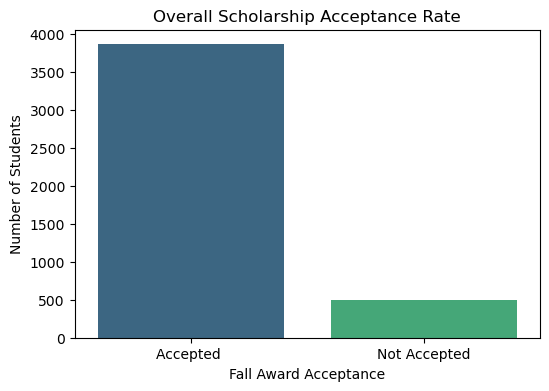

In [27]:
# Count of acceptance
acceptance_counts = df_clean['Fall award Acceptance'].value_counts()

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=acceptance_counts.index, y=acceptance_counts.values, palette="viridis")
plt.title('Overall Scholarship Acceptance Rate')
plt.xlabel('Fall Award Acceptance')
plt.ylabel('Number of Students')
plt.show()

In [28]:
# Total number of students
total_students = len(df_clean)

# Number of students who accepted
accepted_students = df_clean['Fall award Acceptance'].value_counts().get('Accepted ', 0)

# Acceptance rate (%)
acceptance_rate = (accepted_students / total_students) * 100

accepted_students, total_students, acceptance_rate

(3864, 4357, 88.6848749139316)

In [18]:
df_clean['Fall award Acceptance'].unique()

array(['Accepted ', 'Not Accepted'], dtype=object)

An overall acceptance rate of **88.7%** is high, but for understading equity and trends across subgroups by diving deeper will give them actionable insights.

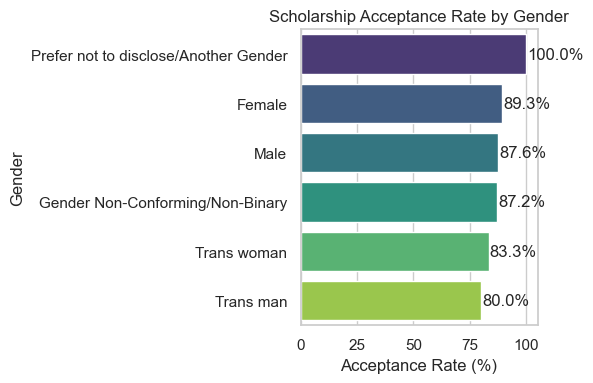

In [31]:
# Set plot style
sns.set(style="whitegrid")

# Gender acceptance rate
gender_acceptance = (df_clean.groupby('Gender')['Fall award Acceptance']
                     .apply(lambda x: (x=='Accepted ').mean()*100)
                     .sort_values(ascending=False))

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=gender_acceptance.values, y=gender_acceptance.index, palette="viridis")
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Gender')
plt.title('Scholarship Acceptance Rate by Gender')

# Annotate bars
for i, v in enumerate(gender_acceptance.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

Looking at acceptance rates by gender, we see that students who preferred not to disclose had the highest acceptance at 100%. Female students accepted at 89.3%, males at 87.6%, and non-binary students at 87.2%. Trans women and trans men had slightly lower acceptance rates at 83.3% and 80%, respectively. Overall, acceptance is high across all groups, though these differences highlight the importance of ensuring support and outreach is equitable for all students.

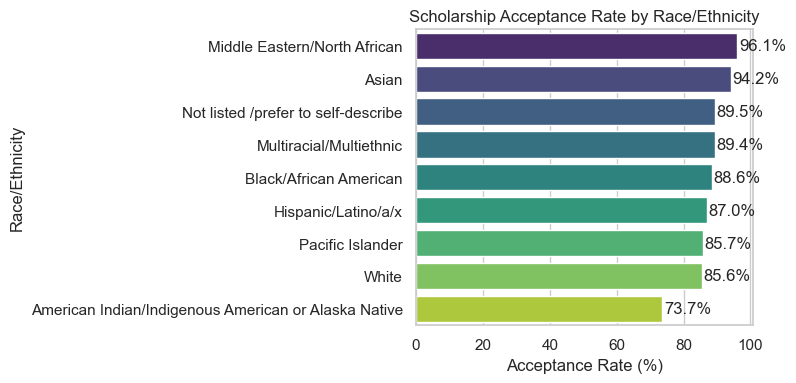

In [32]:
# Race/Ethnicity acceptance rate
race_acceptance = (df_clean.groupby('Race/Ethnicity')['Fall award Acceptance']
                   .apply(lambda x: (x=='Accepted ').mean()*100)
                   .sort_values(ascending=False))

# Bar plot
plt.figure(figsize=(8,4))
sns.barplot(x=race_acceptance.values, y=race_acceptance.index, palette="viridis")
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Race/Ethnicity')
plt.title('Scholarship Acceptance Rate by Race/Ethnicity')

# Annotate bars
for i, v in enumerate(race_acceptance.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()


Acceptance rates vary across racial and ethnic groups. Middle Eastern/North African and Asian students show the highest acceptance rates, while White and American Indian students have the lowest. Overall, most groups have strong acceptance, but these differences could inform targeted outreach and support to ensure equitable engagement across all communities.

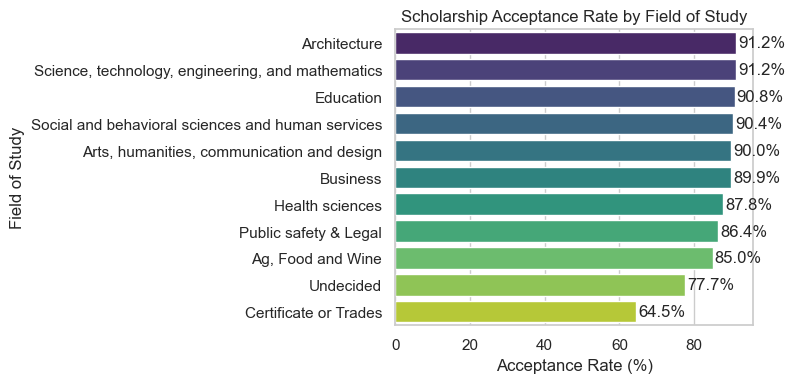

In [33]:
# Field of Study acceptance rate
field_acceptance = (df_clean.groupby('Field of Study')['Fall award Acceptance']
                    .apply(lambda x: (x=='Accepted ').mean()*100)
                    .sort_values(ascending=False))

# Bar plot
plt.figure(figsize=(8,4))
sns.barplot(x=field_acceptance.values, y=field_acceptance.index, palette="viridis")
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Field of Study')
plt.title('Scholarship Acceptance Rate by Field of Study')

# Annotate bars
for i, v in enumerate(field_acceptance.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

Looking at acceptance by field of study, students pursuing Architecture and Science have the highest acceptance rates, while those in Undecided or Trades fields show the lowest. This suggests that program engagement or awareness may vary by field, and targeted support could help ensure all students fully consider and accept their awards.

Let's focus on **Application Type** and analyze the **Renewal rate** basically, the proportion of students who are renewals vs new applicants.

Renewal rate: 71.5%


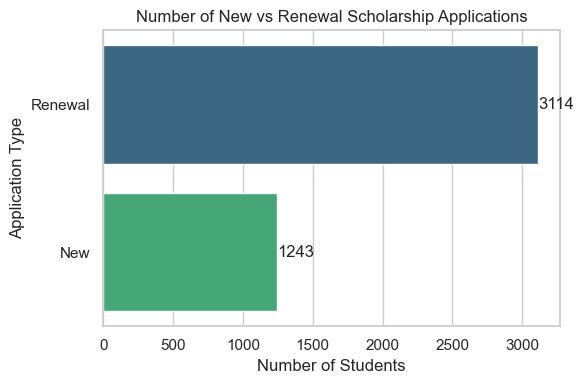

In [35]:
# Renewal vs New counts
application_counts = df_clean['Application Type'].value_counts()

# Renewal rate (% of renewals)
renewal_rate = (application_counts.get('Renewal', 0) / application_counts.sum()) * 100

print(f"Renewal rate: {renewal_rate:.1f}%")

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=application_counts.values, y=application_counts.index, palette="viridis")
plt.xlabel('Number of Students')
plt.ylabel('Application Type')
plt.title('Number of New vs Renewal Scholarship Applications')

# Annotate bars
for i, v in enumerate(application_counts.values):
    plt.text(v + 5, i, f"{v}", va='center')

plt.tight_layout()
plt.show()


About 71.5% of scholarship recipients are renewing their awards, which indicates strong program engagement and that the majority of students are continuing to benefit from the support. This high renewal rate suggests students are using the scholarship effectively to stay enrolled and persist in their education.

Let's look at **Partner High School participation** to see where this students are coming from, whether students came from a partner high school or not. This will help and show the impact of high school programs.

In [37]:
df_clean['Attended Partner High School'].unique()

array([0, 1])

Percentage of students from partner high schools: 69.4%


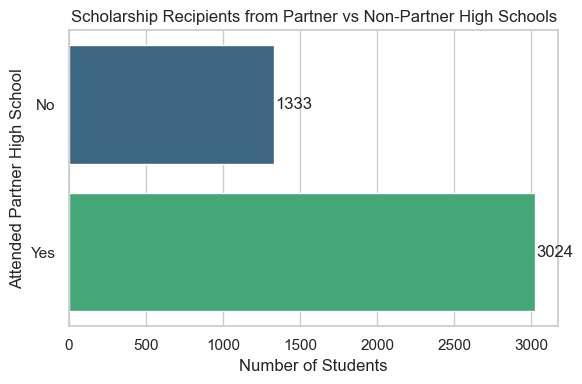

In [ ]:
# Partner High School counts
partner_counts = df_clean['Attended Partner High School'].value_counts().sort_index()
# Map 0/1 to labels 
partner_counts.index = ['No', 'Yes']

# Percentage from partner schools
partner_percent = (partner_counts['Yes'] / partner_counts.sum()) * 100
print(f"Percentage of students from partner high schools: {partner_percent:.1f}%")

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=partner_counts.values, y=partner_counts.index, palette="viridis")
plt.xlabel('Number of Students')
plt.ylabel('Attended Partner High School')
plt.title('Scholarship Recipients from Partner vs Non-Partner High Schools')

# Annotate bars
for i, v in enumerate(partner_counts.values):
    plt.text(v + 5, i, f"{v}", va='center')

plt.tight_layout()
plt.show()


Out of 4,357 students, 3,024 attended partner high schools while 1,333 did not. This shows that high school partnerships are highly effective in connecting students to scholarship opportunities. Maintaining and expanding these partnerships can further increase program reach and ensure more students benefit from the scholarship.

Now let's analyze **First Generation students** whether they are the first in their family to attend college.

In [39]:
df_clean['First Generation'].unique()

array(['No', 'Yes', "I don't know"], dtype=object)

Percentage of first-generation students: 82.7%


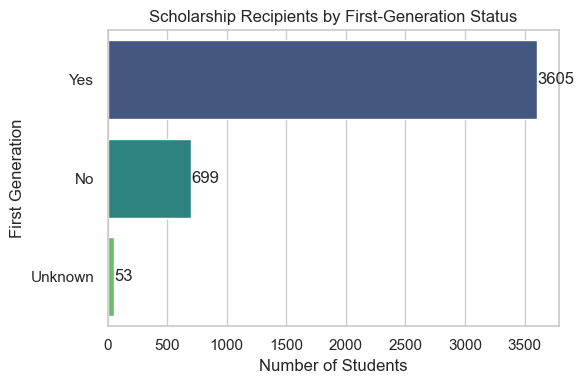

In [40]:
# Count values
first_gen_counts = df_clean['First Generation'].value_counts()

# Rename for readability
first_gen_counts.index = first_gen_counts.index.map({
    'Yes': 'Yes',
    'No': 'No',
    "I don't know": 'Unknown'
})

# Percentage of first-generation students
first_gen_percent = (first_gen_counts['Yes'] / first_gen_counts.sum()) * 100
print(f"Percentage of first-generation students: {first_gen_percent:.1f}%")

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=first_gen_counts.values, y=first_gen_counts.index, palette="viridis")
plt.xlabel('Number of Students')
plt.ylabel('First Generation')
plt.title('Scholarship Recipients by First-Generation Status')

# Annotate bars
for i, v in enumerate(first_gen_counts.values):
    plt.text(v + 5, i, f"{v}", va='center')

plt.tight_layout()
plt.show()


Out of 4,357 students, 3,605 are first-generation college students, 699 are not, and 53 are unknown. This shows that **the scholarship program is strongly supporting students who are the first in their family to attend college**, highlighting the program’s impact on promoting educational equity and opportunity. Continuing to prioritize first-generation students ensures the program reaches those who may face additional barriers to higher education.

Lastly, let's go over with the **Total Offered Award Amount**. This can help and understand scholarship distribution and see if any trends exist across students.

In [41]:
# Summary statistics
df_clean['Total Offered Award Amount'].describe()


count     4357.000000
mean      2226.046970
std       4891.107665
min        500.000000
25%       1000.000000
50%       1000.000000
75%       1500.000000
max      69148.000000
Name: Total Offered Award Amount, dtype: float64

The total scholarship award amounts range from $500 to $69,148, with a **median of $1,000** and an average of **$2,226**. Most students receive awards between $1,000 and $1,500, though a few students receive much larger amounts, which likely reflect special or multi-year scholarships. This overview helps leadership understand how funds are distributed and can inform future allocation or targeted support for students.

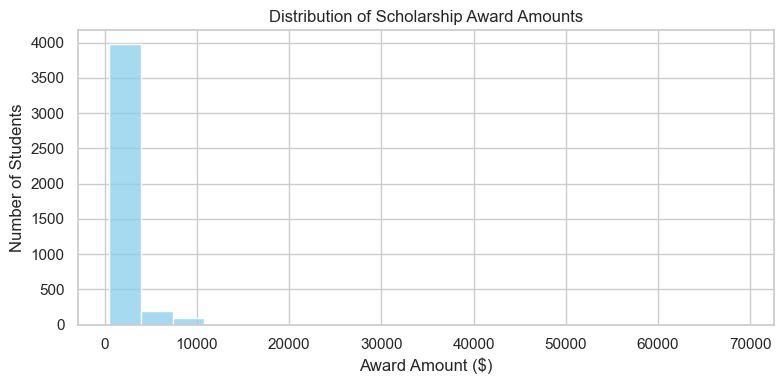

In [42]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean['Total Offered Award Amount'], bins=20, kde=False, color='skyblue')
plt.xlabel('Award Amount ($)')
plt.ylabel('Number of Students')
plt.title('Distribution of Scholarship Award Amounts')
plt.tight_layout()
plt.show()


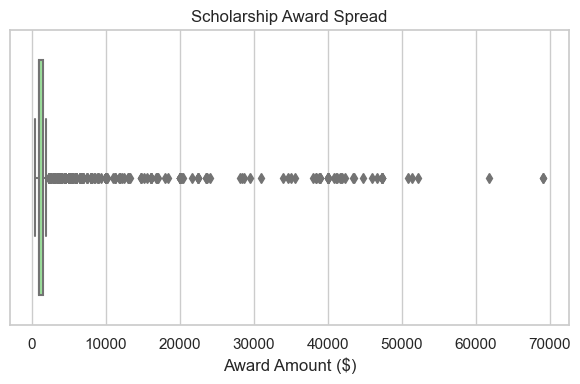

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['Total Offered Award Amount'], color='lightgreen')
plt.xlabel('Award Amount ($)')
plt.title('Scholarship Award Spread')
plt.tight_layout()
plt.show()


The max value ($69,148) is an extreme outlier compared to most awards, so if you plot all values with default scale, the histogram is very skewed. Following plot is more readable.

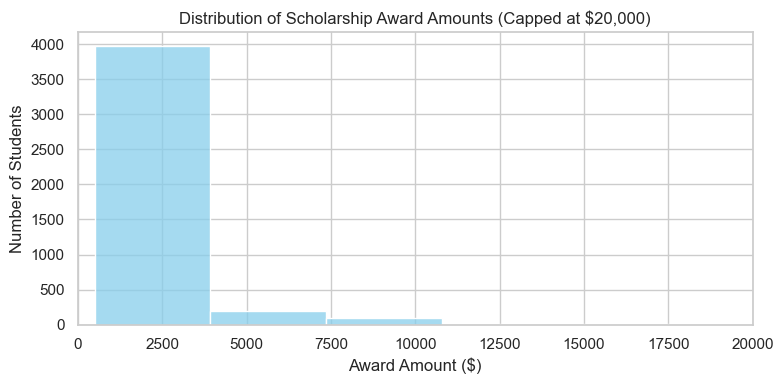

In [44]:
# Histogram with x-axis capped at 20,000
plt.figure(figsize=(8,4))
sns.histplot(df_clean['Total Offered Award Amount'], bins=20, kde=False, color='skyblue')
plt.xlim(0, 20000)  # Focus on awards below 20k
plt.xlabel('Award Amount ($)')
plt.ylabel('Number of Students')
plt.title('Distribution of Scholarship Award Amounts (Capped at $20,000)')
plt.tight_layout()
plt.show()

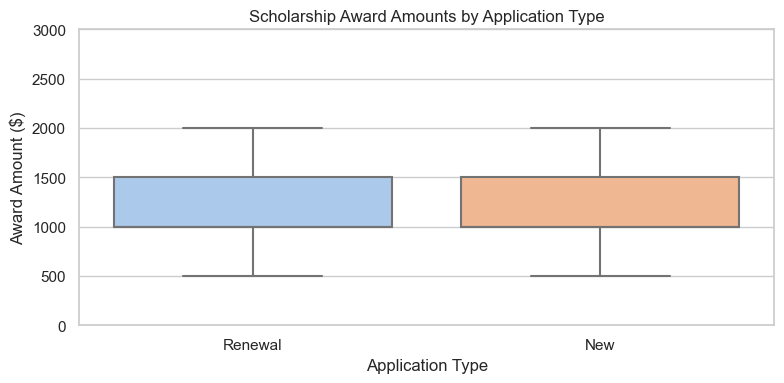

In [46]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x='Application Type',
    y='Total Offered Award Amount',
    data=df_clean,
    showfliers=False,  # hides extreme outliers for clarity
    palette='pastel'
)
plt.ylim(0, 3000)  # focus on the majority of awards
plt.ylabel('Award Amount ($)')
plt.title('Scholarship Award Amounts by Application Type')
plt.tight_layout()
plt.show()


Let's briefly go over to analyze the impact of financial aid using the sample data. Since we don’t have “before/after” outcomes in the dataset, we can illustrate the A/B style comparison using available columns.

For instance,

* Application Type (New vs Renewal)

* Fall award Acceptance (Accepted vs Not)

* Total Offered Award Amount


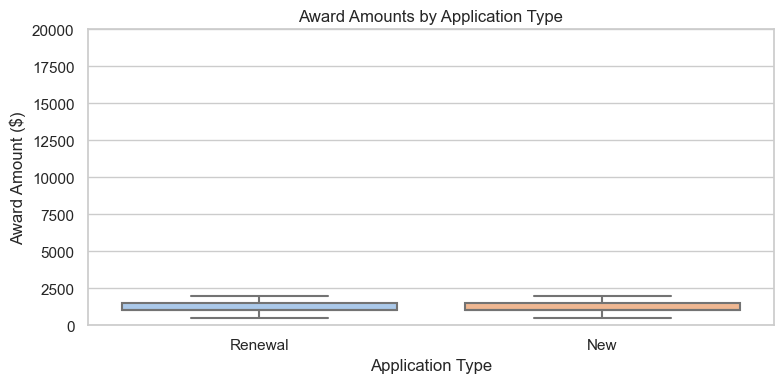

In [47]:
# Boxplot for award by application type
plt.figure(figsize=(8,4))
sns.boxplot(
    x='Application Type', 
    y='Total Offered Award Amount', 
    data=df_clean, 
    showfliers=False,
    palette='pastel'
)
plt.ylim(0, 20000)
plt.ylabel('Award Amount ($)')
plt.title('Award Amounts by Application Type')
plt.tight_layout()
plt.show()

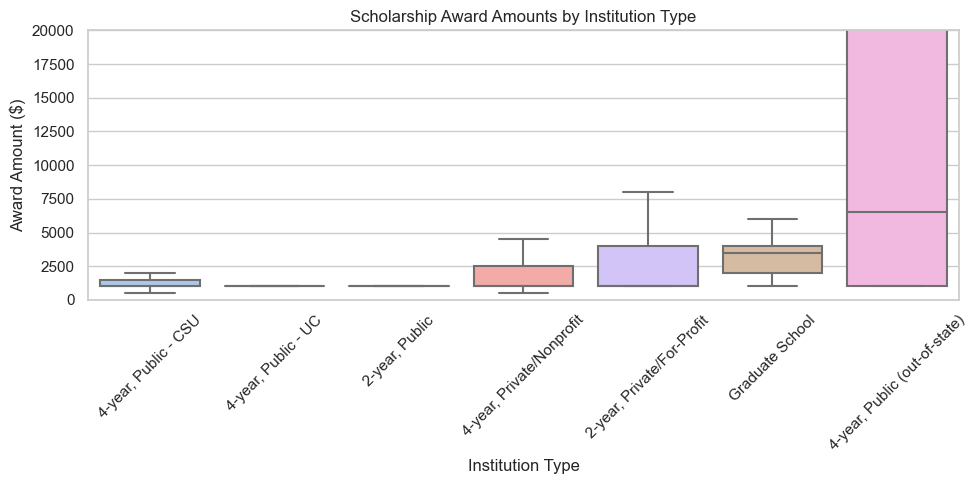

In [52]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Institution Type',
    y='Total Offered Award Amount',
    data=df_clean,
    showfliers=False,  # hides extreme outliers
    palette='pastel'
)
plt.ylim(0, 20000)  # focus on majority of awards
plt.ylabel('Award Amount ($)')
plt.xlabel('Institution Type')
plt.title('Scholarship Award Amounts by Institution Type')
plt.xticks(rotation=45)  # rotate labels for readability
plt.tight_layout()
plt.show()
